In [35]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

In [ ]:
df = pd.read_csv("data/tiktok_dataset.csv")

In [65]:
df

,#,claim_status,video_id,video_duration_sec,video_transcription_text,verified_status,author_ban_status,video_view_count,video_like_count,video_share_count,video_download_count,video_comment_count
0,1,claim,7017666017,59,someone shared with me that drone deliveries a...,not verified,under review,343296.0,19425.0,241.0,1.0,0.0
1,2,claim,4014381136,32,someone shared with me that there are more mic...,not verified,active,140877.0,77355.0,19034.0,1161.0,684.0
2,3,claim,9859838091,31,someone shared with me that american industria...,not verified,active,902185.0,97690.0,2858.0,833.0,329.0
3,4,claim,1866847991,25,someone shared with me that the metro of st. p...,not verified,active,437506.0,239954.0,34812.0,1234.0,584.0
4,5,claim,7105231098,19,someone shared with me that the number of busi...,not verified,active,56167.0,34987.0,4110.0,547.0,152.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19377,19378,NaN,7578226840,21,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19378,19379,NaN,6079236179,53,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN
19379,19380,NaN,2565539685,10,NaN,verified,under review,NaN,NaN,NaN,NaN,NaN
19380,19381,NaN,2969178540,24,NaN,not verified,active,NaN,NaN,NaN,NaN,NaN


In [66]:
num_cols = ['video_view_count', 'video_like_count', 'video_share_count',
            'video_download_count', 'video_comment_count', 'video_duration_sec']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

# 2. FEATURE ENGINEERING (Rubric: Reasoning for Decisions)
# We define virality based on play_count (e.g., top 10% or above median)
le = LabelEncoder()
cat_cols = ['verified_status', 'author_ban_status']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

threshold = df['video_view_count'].median()
df['is_viral'] = (df['video_view_count'] > threshold).astype(int)

In [67]:
threshold

9788.0

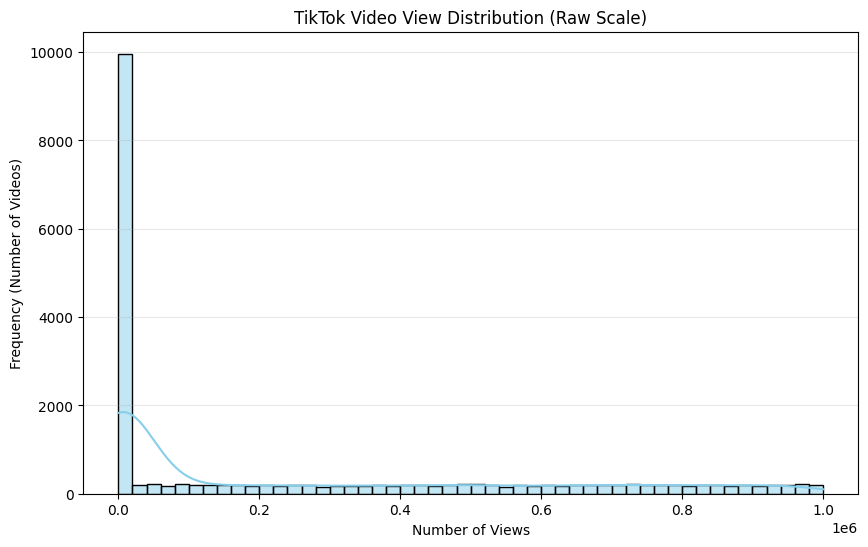

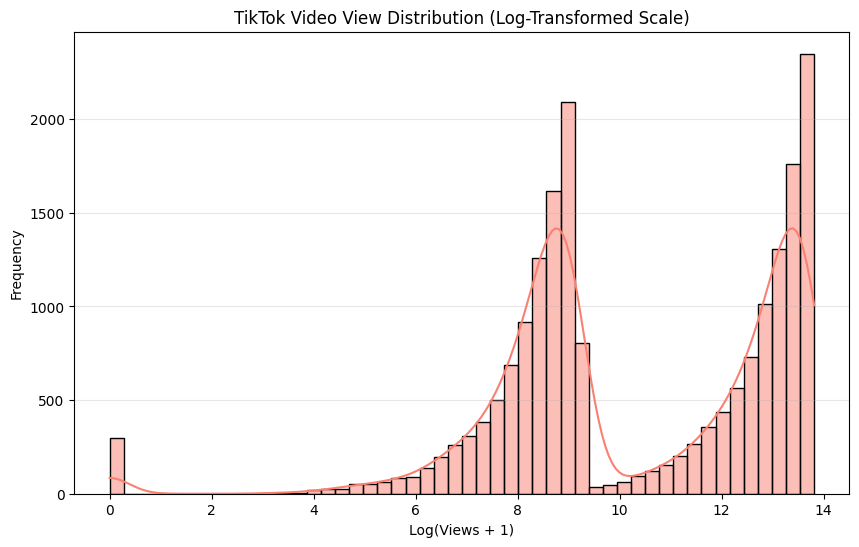

Median Views: 9788.0
Mean Views: 250792.39
Skewness: 0.95


In [68]:
plt.figure(figsize=(10, 6))
sns.histplot(df['video_view_count'], bins=50, kde=True, color='skyblue')
plt.title('TikTok Video View Distribution (Raw Scale)')
plt.xlabel('Number of Views')
plt.ylabel('Frequency (Number of Videos)')
plt.grid(axis='y', alpha=0.3)
plt.show()

# FIGURE 2: Log-Transformed Distribution
plt.figure(figsize=(10, 6))
# np.log1p handles zero views by calculating log(1 + x)
sns.histplot(np.log1p(df['video_view_count']), bins=50, kde=True, color='salmon')
plt.title('TikTok Video View Distribution (Log-Transformed Scale)')
plt.xlabel('Log(Views + 1)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)
plt.show()

# 3. STATISTICAL SUMMARY FOR INTERPRETATION [Rubric Section 4]
print(f"Median Views: {df['video_view_count'].median()}")
print(f"Mean Views: {df['video_view_count'].mean():.2f}")
print(f"Skewness: {df['video_view_count'].skew():.2f}")

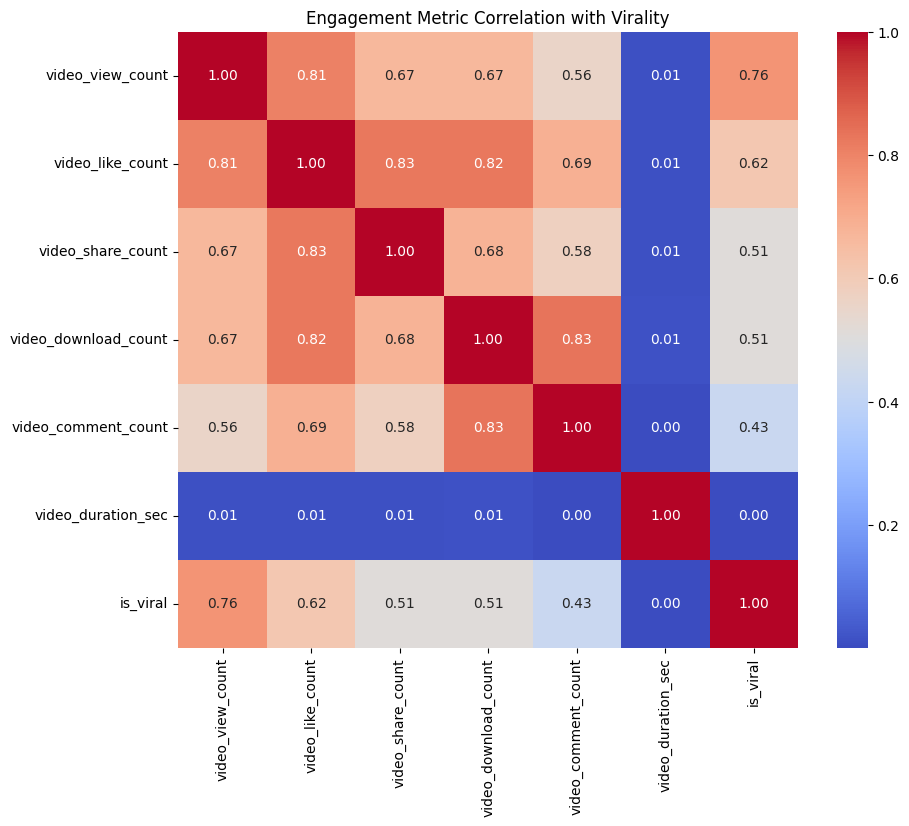

In [70]:
# Select only numeric engagement columns for the heatmap

plt.figure(figsize=(10, 8))
corr = df[num_cols + ['is_viral']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Engagement Metric Correlation with Virality")
plt.show()



/tmp/ipykernel_1944/1911377540.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=bin_counts.index, y=bin_counts.values, palette='viridis')


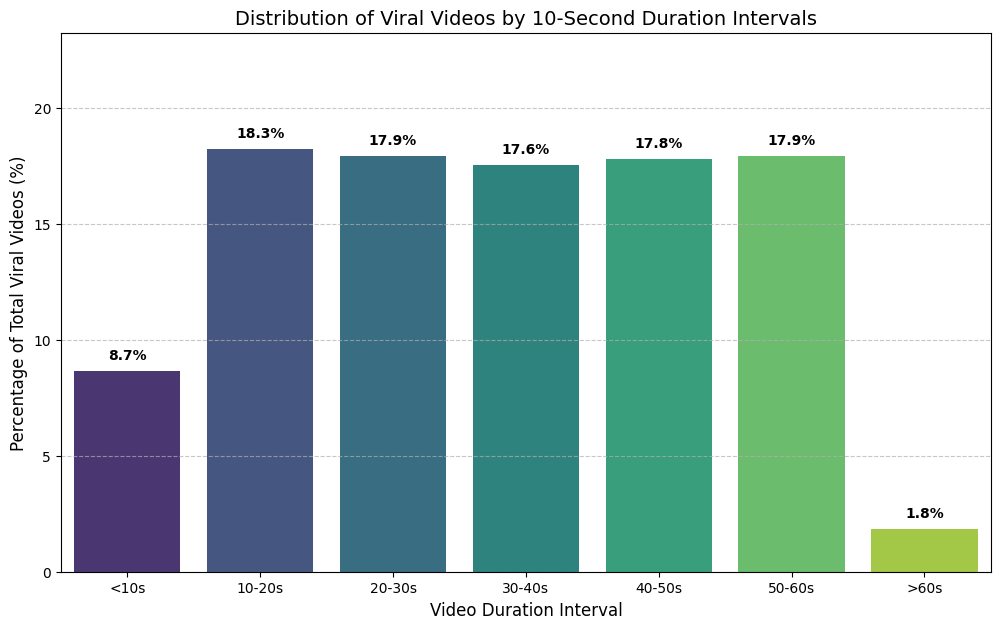

In [71]:
# Using a scatter plot with alpha to see density and hue to distinguish viral status
bins = [0, 10, 20, 30, 40, 50, 60, np.inf]
labels = ['<10s', '10-20s', '20-30s', '30-40s', '40-50s', '50-60s', '>60s']

# Create the duration bin column
df['duration_bin'] = pd.cut(df['video_duration_sec'], bins=bins, labels=labels, right=False)

# --- 3. ANALYSIS OF VIRAL VIDEOS ONLY ---
viral_df = df[df['is_viral'] == 1]
# Calculate the percentage of viral videos in each bin
bin_counts = viral_df['duration_bin'].value_counts(normalize=True).sort_index() * 100

# --- 4. PLOTTING ---
plt.figure(figsize=(12, 7))
sns.barplot(x=bin_counts.index, y=bin_counts.values, palette='viridis')

plt.title("Distribution of Viral Videos by 10-Second Duration Intervals", fontsize=14)
plt.xlabel("Video Duration Interval", fontsize=12)
plt.ylabel("Percentage of Total Viral Videos (%)", fontsize=12)
plt.ylim(0, max(bin_counts.values) + 5) # Add space for labels

# Add percentage labels on top of bars
for i, val in enumerate(bin_counts.values):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

/tmp/ipykernel_1944/94107464.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='is_viral', y=np.log1p(df['video_share_count']), palette='Set2')


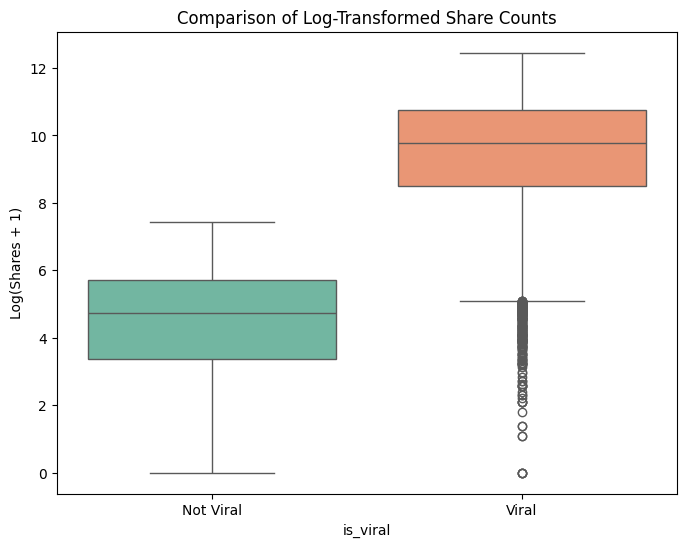

In [72]:
plt.figure(figsize=(8, 6))
# Apply log-transformation to the y-axis data for better visualization
sns.boxplot(data=df, x='is_viral', y=np.log1p(df['video_share_count']), palette='Set2')
plt.title("Comparison of Log-Transformed Share Counts")
plt.xticks([0, 1], ['Not Viral', 'Viral'])
plt.ylabel("Log(Shares + 1)")
plt.show()

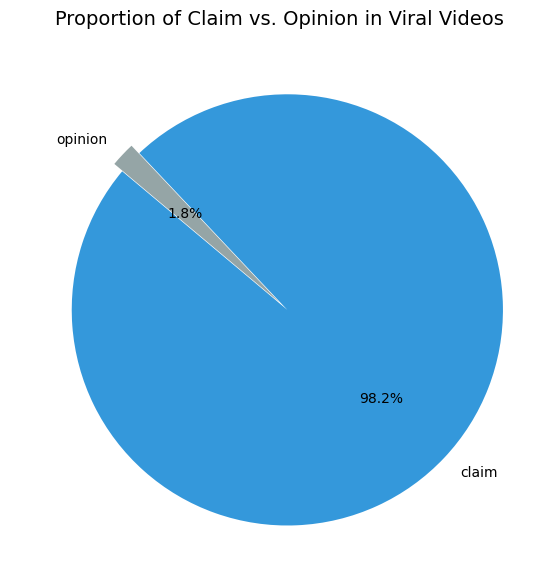

Claim Status breakdown for Viral Videos:
claim_status
claim      9512
opinion     179
Name: count, dtype: int64


In [78]:


# --- 3. PLOTTING ---
viral_df = df[df['is_viral'] == 1]
claim_counts = viral_df['claim_status'].value_counts()

# --- 3. PLOTTING THE PROPORTION ---
plt.figure(figsize=(9, 7))
colors = ['#3498db', '#95a5a6'] # Blue for Claim, Gray for Opinion

plt.pie(claim_counts,
        labels=claim_counts.index,
        autopct='%1.1f%%',
        startangle=140,
        colors=colors,
        explode=(0.05, 0)) # Highlight the largest portion

plt.title("Proportion of Claim vs. Opinion in Viral Videos", fontsize=14)
plt.show()

# Print counts for meeting notes
print("Claim Status breakdown for Viral Videos:")
print(claim_counts)


--- Baseline Results ---
ROC-AUC Score: 0.9888

Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1939
           1       1.00      0.95      0.97      1938

    accuracy                           0.97      3877
   macro avg       0.98      0.97      0.97      3877
weighted avg       0.98      0.97      0.97      3877



/tmp/ipykernel_1944/4057034111.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


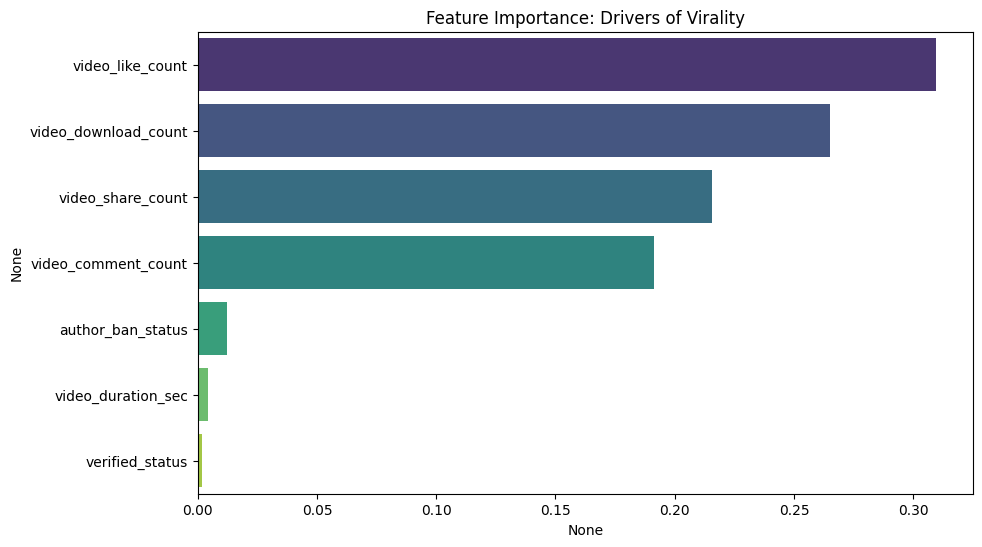

In [76]:
features = ['video_duration_sec', 'verified_status', 'author_ban_status',
             'video_like_count', 'video_share_count',
            'video_download_count', 'video_comment_count']

X = df[features]
y = df['is_viral']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)

# Output Results
probs = rf_model.predict_proba(X_test)[:, 1]
print("--- Baseline Results ---")
print(f"ROC-AUC Score: {roc_auc_score(y_test, probs):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_model.predict(X_test)))

# Feature Importance Visualization [Rubric Section 1]
importances = pd.Series(rf_model.feature_importances_, index=features).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title("Feature Importance: Drivers of Virality")
plt.show()